# P6 → Ocean thermal and haline change contributions to Sea Level trends

## Introduction
Sea level increases because of changes in currents (dynamic effect) and because of ocean density changes (steric effect). Hence, Sea surface height increases not only as water is added or transported, but also as water warms and its volume expands. Changes in salt content, or salinity, also affect sea levels. These are known as “thermosteric” and “halosteric” changes. This project is about caracterising and looking at the steric contribution to Sea Level Change.

You will need to compute ocean density changes contribution to Sea level rises (thermosteric and halosteric effects) and demonstrate that it is the driver of regional sea level change trends.

*Bibliography*:

- [Ocean and climate scientific sheet](https://ocean-climate.org/wp-content/uploads/2015/03/sea-level_ScientificItems_BD-3.pdf)
- [Overview](https://sealevel.nasa.gov/understanding-sea-level/overview)
- [Deep-ocean contribution to sea level and energy budget not detectable over the past decade](https://www.nature.com/articles/nclimate2387)
- [Last IPCC report on Sea Level changes](https://www.ipcc.ch/report/ar6/wg1/downloads/report/IPCC_AR6_WGI_Chapter_09.pdf#page=55)
- [IPCC fig 9.12](https://www.ipcc.ch/report/ar6/wg1/downloads/report/IPCC_AR6_WGI_Chapter_09.pdf#page=237)
- [Meyssignac et al, 2012](https://www.sciencedirect.com/science/article/pii/S0264370712000464)

*Ideas for your project*

Below is a list of what you could do in a timely manner in your project.

You shall first compute the Sea Level trend and remove its global average. This local trend will be the pattern to explain.

Then you should compute the thermal and haline contribution to steric height. To do so you will use the GSW librairy that will help you compute the absolute salinity, conservative temperature and them the thermal expansion and haline contraction coefficient.

You may compare the Sea Level trend from altimetry with the steric height from observations. Be careful to compare similar time period.

Using the bibliography, you may consider to compare your results with already published ones, to ensure the accuracy of your computation.

The EN4 dataset to work with is a global interpolation of all available ocean in-situ observations. You could further compare CMIP6 projections or historical simulations to the EN4 reference.

## Description

The Steric contribution to Sea Level Anomaly (SSLA) is computed as the vertical integral of density anomalies:
$$SSLA = \frac{-1}{\rho_0}\int_{-H}^{0} \Delta \rho \,dz$$
which can be further decomposed into thermosteric (temperature) and halosteric (salinity) contributions:
$$SSLA = TSLA + HSLA$$
with:
$$TSLA = -\int_{-H}^{0} \alpha \Delta T \,dz$$
$$HSLA =  \int_{-H}^{0} \beta \Delta S \,dz$$

where:
- $\Delta \rho$ the density anomaly, refered to a climatic mean,
- $\Delta T$ the temperature anomaly, refered to a climatic mean,
- $\Delta S$ the salinity anomaly, refered to a climatic mean,
- $\rho_0$ is the reference density $1025 kg/m^{3}$, 
- $\alpha$ is the ocean thermal expansion coefficient,
- $\beta$ the haline contraction coefficient,
- $H$ is the reference depth, set to 700, 1000 or 2000m.

$\alpha$ and $\beta$ can be computed with the [GSW library](https://teos-10.github.io/GSW-Python/).

Note that you should take of the irregular area and thickness of the grid cells when computing horizontal or vertical averages/integrals ([see the P5 notebook](https://github.com/obidam/ds2-2025/blob/main/projects/P5-OceanWarming-for-students.ipynb)).

All ocean variables can be obtained directly from the EN4 dataset. Be careful with units. The Sea Level Change from altimetry data is obtainted from the AVISO dataset, also provided by the class data catalogue.

The main problem in this project is to calculate $TSLA$ and $HSLA$.

# Getting started

## Load all the necessary libraries

In [4]:
import os, sys, urllib, tempfile
with tempfile.TemporaryDirectory() as tmpdirname:
    sys.path.append(tmpdirname)
    repo = "https://raw.githubusercontent.com/obidam/ds2-2025/main/"
    urllib.request.urlretrieve(os.path.join(repo, "utils.py"), 
                               os.path.join(tmpdirname, "utils.py"))
    from utils import check_up_env
    ds2tools = check_up_env(with_tuto=True)

/var/folders/d9/0nz594d537nf67624bls5jzc0000gn/T/tmpcu99cygg/utils.py:69: UserWarning: 
Running on your own environment
Make sure to have all necessary packages installed
See:   https://github.com/obidam/ds2-2025/blob/main/practice/environment/coiled/environment-coiled-pinned-binder.yml
  warnings.warn("\nRunning on your own environment\nMake sure to have all necessary packages installed\nSee:   https://github.com/obidam/ds2-2025/blob/main/practice/environment/coiled/environment-coiled-pinned-binder.yml")


In [5]:
import numpy as np
import pandas as pd
import xarray as xr
from scipy import stats
import dask

from intake import open_catalog
import gsw

import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
create_map = ds2tools.create_map

## Connect to the data catalog

In [6]:
catalog_url = 'https://raw.githubusercontent.com/obidam/ds2-2025/main/ds2_data_catalog.yml'
cat = open_catalog(catalog_url)
cat

ds2_data_catalog:
  args:
    path: https://raw.githubusercontent.com/obidam/ds2-2025/main/ds2_data_catalog.yml
  description: ''
  driver: intake.catalog.local.YAMLFileCatalog
  metadata: {}


In [7]:
# Load ocean dataset EN4
en4 = cat["en4"].to_dask()
print("Size of the dataset:", en4.nbytes/1e9,"Gb")
en4

Size of the dataset: 52.2317975 Gb


/Users/mac/anaconda3/envs/ds2-coiled-2025-binder/lib/python3.11/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<xarray.Dataset>
Dimensions:                          (depth: 42, time: 832, bnds: 2, lat: 173,
                                      lon: 360)
Coordinates:
  * depth                            (depth) float32 5.022 15.08 ... 5.35e+03
  * lat                              (lat) float32 -83.0 -82.0 ... 88.0 89.0
  * lon                              (lon) float32 1.0 2.0 3.0 ... 359.0 360.0
  * time                             (time) datetime64[ns] 1950-01-16T12:00:0...
Dimensions without coordinates: bnds
Data variables:
    depth_bnds                       (time, depth, bnds) float32 dask.array<chunksize=(1, 42, 2), meta=np.ndarray>
    salinity                         (time, depth, lat, lon) float32 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
    salinity_observation_weights     (time, depth, lat, lon) float32 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
    salinity_uncertainty             (time, depth, lat, lon) float32 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
    temperature                      (time, depth, lat, lon) float32 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
    temperature_observation_weights  (time, depth, lat, lon) float32 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
    temperature_uncertainty          (time, depth, lat, lon) float32 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
    time_bnds                        (time, bnds) datetime64[ns] dask.array<chunksize=(832, 2), meta=np.ndarray>
Attributes: (12/21)
    Conventions:            CF-1.0
    DSD_entry_id:           UKMO-L4UHFnd-GLOB-v01
    GDS_version_id:         v1.7
    contact:                Simon Good - simon.good@metoffice.gov.uk
    creation_date:          2017-04-21 21:12:08.123 -00:00
    easternmost_longitude:  362.5
    ...                     ...
    start_date:             2001-01-01 UTC
    start_time:             00:00:00 UTC
    stop_date:              2001-01-01 UTC
    stop_time:              00:00:00 UTC
    title:                  Temperature and salinity analysis
    westernmost_longitude:  0.5

In [8]:
# Load Sea Level Anomalies from altimetry:
ssh = cat["sea_surface_height"].to_dask()
print("Size of the dataset:", ssh.nbytes/1e9,"Gb")
ssh

Size of the dataset: 18.1203746 Gb


/Users/mac/anaconda3/envs/ds2-coiled-2025-binder/lib/python3.11/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<xarray.Dataset>
Dimensions:    (time: 312, latitude: 720, longitude: 1440, nv: 2)
Coordinates:
  * latitude   (latitude) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * longitude  (longitude) float32 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
  * nv         (nv) int32 0 1
  * time       (time) datetime64[ns] 1993-01-01 1993-02-01 ... 2018-12-01
Data variables:
    adt        (time, latitude, longitude) float64 dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    crs        (time) float64 dask.array<chunksize=(1,), meta=np.ndarray>
    err        (time, latitude, longitude) float64 dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    lat_bnds   (time, latitude, nv) float32 dask.array<chunksize=(1, 720, 2), meta=np.ndarray>
    lon_bnds   (time, longitude, nv) float32 dask.array<chunksize=(1, 1440, 2), meta=np.ndarray>
    sla        (time, latitude, longitude) float64 dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    ugos       (time, latitude, longitude) float64 dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    ugosa      (time, latitude, longitude) float64 dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    vgos       (time, latitude, longitude) float64 dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    vgosa      (time, latitude, longitude) float64 dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
Attributes: (12/44)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    Note:                            Generated by G. Maze with 31 daily files
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    summary:                         SSALTO/DUACS Delayed-Time Level-4 sea su...
    time_coverage_duration:          P1D
    time_coverage_end:               1993-01-31T12:00:00Z
    time_coverage_resolution:        P1D
    time_coverage_start:             1993-01-30T12:00:00Z
    title:                           DT merged all satellites Global Ocean Gr...

## Connect to a Coiled Dask cluster

For computational expensive operation, you better connect to the Coiled Dask cluster available to the class:

In [ ]:
import coiled
cluster = coiled.Cluster(name="ds2-project6", workspace="class-2025")
# cluster = coiled.Cluster(name="ds2-highmem-binder", workspace="class-2025")
client = cluster.get_client()

[2025-01-21 14:43:00,075][INFO    ][coiled] Using existing cluster: 'ds2-project6 (id: 734388)'
[2025-01-21 14:43:00,076][INFO    ][coiled] Attaching to existing cluster (name: ds2-project6, https://cloud.coiled.io/clusters/734388?account=class-2025 )


2025-01-21 19:34:35,622 - distributed.deploy.cluster - WARNING - Failed to sync cluster info multiple times - perhaps there's a connection issue? Error:
Traceback (most recent call last):
  File "/Users/mac/anaconda3/envs/ds2-coiled-2025-binder/lib/python3.11/site-packages/tornado/iostream.py", line 1181, in connect
    self.socket.connect(address)
OSError: [Errno 51] Network is unreachable

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/Users/mac/anaconda3/envs/ds2-coiled-2025-binder/lib/python3.11/site-packages/distributed/comm/core.py", line 342, in connect
    comm = await wait_for(
           ^^^^^^^^^^^^^^^
  File "/Users/mac/anaconda3/envs/ds2-coiled-2025-binder/lib/python3.11/site-packages/distributed/utils.py", line 1935, in wait_for
    return await fut
           ^^^^^^^^^
  File "/Users/mac/anaconda3/envs/ds2-coiled-2025-binder/lib/python3.11/site-packages/distributed/comm/tcp.py", line 558, in connect
    c

# Sea Level Change from Altimetry
Before moving on to computing TSLA and HSLA, you can compute time series and maps of the SSH variable to familiarize with it.

### Surface elements for global horizontal averaging
To compute a global mean, you need to weight local values with the grid cell areas, in order to account for the latitude dependance of the grid.

We'll be using the formula for the area element in spherical coordinates. The [area element for lat-lon coordinates](https://en.wikipedia.org/wiki/Spherical_coordinate_system#Integration_and_differentiation_in_spherical_coordinates) is

$$ \delta A (x,y) = R^2 \delta \phi \delta \lambda \cos(\phi) $$

where $\phi$ is latitude, $\delta \phi$ is the spacing of the points in latitude, $\delta \lambda$ is the spacing of the points in longitude, and $R$ is Earth's radius. (In this formula, $\phi$ and $\lambda$ are measured in radians.) Let's use xarray to create the weight factor.

Create a function that compute the surface element $\delta A$.

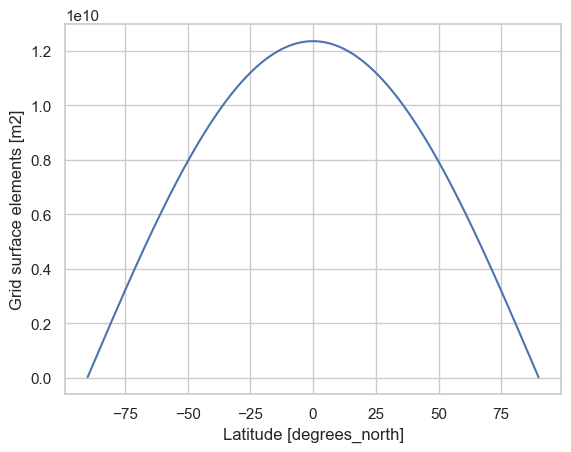

In [10]:
def get_dA(ds):
    # Earth Radius in meters:
    R = 6.37e6  
    # we know already that the spacing of the points is one degree latitude:
    dϕ = np.deg2rad(1.)
    dλ = np.deg2rad(1.)
    # Apply formulae for area element for lat-lon coordinates:
    dA = R**2 * dϕ * dλ * np.cos(np.deg2rad(ds["latitude"]))
    return xr.DataArray(dA, dims='latitude', name='dA', attrs={'unit': 'm2', 'long_name': 'Grid surface elements'})

ssh['dA'] = get_dA(ssh)
ssh['dA'].plot()

We can now compute the sea level anomaly time series:

In [14]:
%%time
gsla = ssh['sla'].weighted(ssh['dA']).mean(dim=['latitude', 'longitude'])

CPU times: user 12.4 ms, sys: 3.76 ms, total: 16.2 ms
Wall time: 20.3 ms


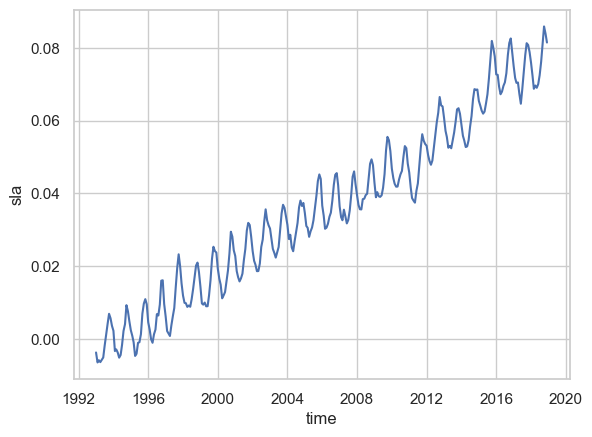

In [15]:
gsla.plot()

### Local Sea Level Trends

What we're realy interested in the local trend of SLA.

To compute local trends, we will let xarray handle the latitude and longitude dimensions and simply works with xarray DataArrays.

Local trends can be computed as the ratio of the time/sla covariance with time variance. 

So let's define the following sum of squares:

for time:
$$ss_{tt} = \Sigma_{i=1}^{N} (t_i - \bar{t})^2$$

for sla:
$$ss_{hh} = \Sigma_{i=1}^{N} (h_i -\bar{h})^2$$

for time/sla:
$$ss_{th} = \Sigma_{i=1}^{N} (t_i - \bar{t})(h_i -\bar{h})$$

Then, the slope of the linear least square fit is simply given by:
$$a = \frac{ss_{th}}{ss_{tt}}$$

If we further estimate the variance for the fit error as:
$$s^2 = \frac{ss_{hh} - a ss_{th}}{N-2}$$

the standard error on the slope $a$ is given by:
$$SE(a) = \frac{s}{\sqrt{ss_{tt}}}$$

Let's now compute all the required sum of squares.

Note that for time, we need to convert the numpy datetime format to a more numerical value, like julian days.

In [16]:
ds = ssh.where(ssh['time']>=pd.to_datetime('19930101'), drop=True).where(ssh['time']<=pd.to_datetime('20100101'), drop=True)
ds

<xarray.Dataset>
Dimensions:    (time: 205, latitude: 720, longitude: 1440, nv: 2)
Coordinates:
  * latitude   (latitude) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * longitude  (longitude) float32 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
  * nv         (nv) int32 0 1
  * time       (time) datetime64[ns] 1993-01-01 1993-02-01 ... 2010-01-01
Data variables:
    adt        (time, latitude, longitude) float64 dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    crs        (time) float64 dask.array<chunksize=(1,), meta=np.ndarray>
    err        (time, latitude, longitude) float64 dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    lat_bnds   (time, latitude, nv) float32 dask.array<chunksize=(1, 720, 2), meta=np.ndarray>
    lon_bnds   (time, longitude, nv) float32 dask.array<chunksize=(1, 1440, 2), meta=np.ndarray>
    sla        (time, latitude, longitude) float64 dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    ugos       (time, latitude, longitude) float64 dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    ugosa      (time, latitude, longitude) float64 dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    vgos       (time, latitude, longitude) float64 dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    vgosa      (time, latitude, longitude) float64 dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    dA         (latitude, time) float32 2.697e+07 2.697e+07 ... 2.697e+07
Attributes: (12/44)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    Note:                            Generated by G. Maze with 31 daily files
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    summary:                         SSALTO/DUACS Delayed-Time Level-4 sea su...
    time_coverage_duration:          P1D
    time_coverage_end:               1993-01-31T12:00:00Z
    time_coverage_resolution:        P1D
    time_coverage_start:             1993-01-30T12:00:00Z
    title:                           DT merged all satellites Global Ocean Gr...

In [19]:
%%time
# For time:
ds['t'] = xr.DataArray(ds['time'].to_pandas().index.to_julian_date().values, dims='time', name='juld')
sstt = ((ds['t']-ds['t'].mean(dim='time'))**2).sum(dim='time')

# For sla:
sshh = ((ds['sla']-ds['sla'].mean(dim='time'))**2).sum(dim='time').compute().persist()

# For time vs sla:
ssth = (((ds['t'] - ds['t'].mean(dim='time')) * (ds['sla'] - ds['sla'].mean(dim='time'))).sum(dim='time')).compute().persist()

CPU times: user 472 ms, sys: 154 ms, total: 626 ms
Wall time: 25.8 s


Let's compute the slope of the linear least square fit:

In [20]:
%%time
ssh['sla_trend'] = ssth / sstt  # m / days
ssh['sla_trend'].compute().persist()
ssh['sla_trend'].values

CPU times: user 2.86 ms, sys: 2.01 ms, total: 4.87 ms
Wall time: 3.5 ms


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

And finaly remove the global sea level trend to get only local anomalies

In [21]:
global_sla_trend = ssh['sla_trend'].weighted(ssh['dA']).mean()
global_sla_trend*365*1000  # mm/year

<xarray.DataArray 'sla_trend' ()>
array(2.0674751)

In [22]:
(ssh['sla_trend']-global_sla_trend)*365*1000

<xarray.DataArray 'sla_trend' (latitude: 720, longitude: 1440)>
array([[-2.0674751, -2.0674751, -2.0674751, ..., -2.0674751, -2.0674751,
        -2.0674751],
       [-2.0674751, -2.0674751, -2.0674751, ..., -2.0674751, -2.0674751,
        -2.0674751],
       [-2.0674751, -2.0674751, -2.0674751, ..., -2.0674751, -2.0674751,
        -2.0674751],
       ...,
       [-2.0674751, -2.0674751, -2.0674751, ..., -2.0674751, -2.0674751,
        -2.0674751],
       [-2.0674751, -2.0674751, -2.0674751, ..., -2.0674751, -2.0674751,
        -2.0674751],
       [-2.0674751, -2.0674751, -2.0674751, ..., -2.0674751, -2.0674751,
        -2.0674751]])
Coordinates:
  * latitude   (latitude) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * longitude  (longitude) float32 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9

Let's now make a nice map of the local SLA trend:

Text(0.5, 1.0, 'Local Sea Level Anomaly trend in mm/year')

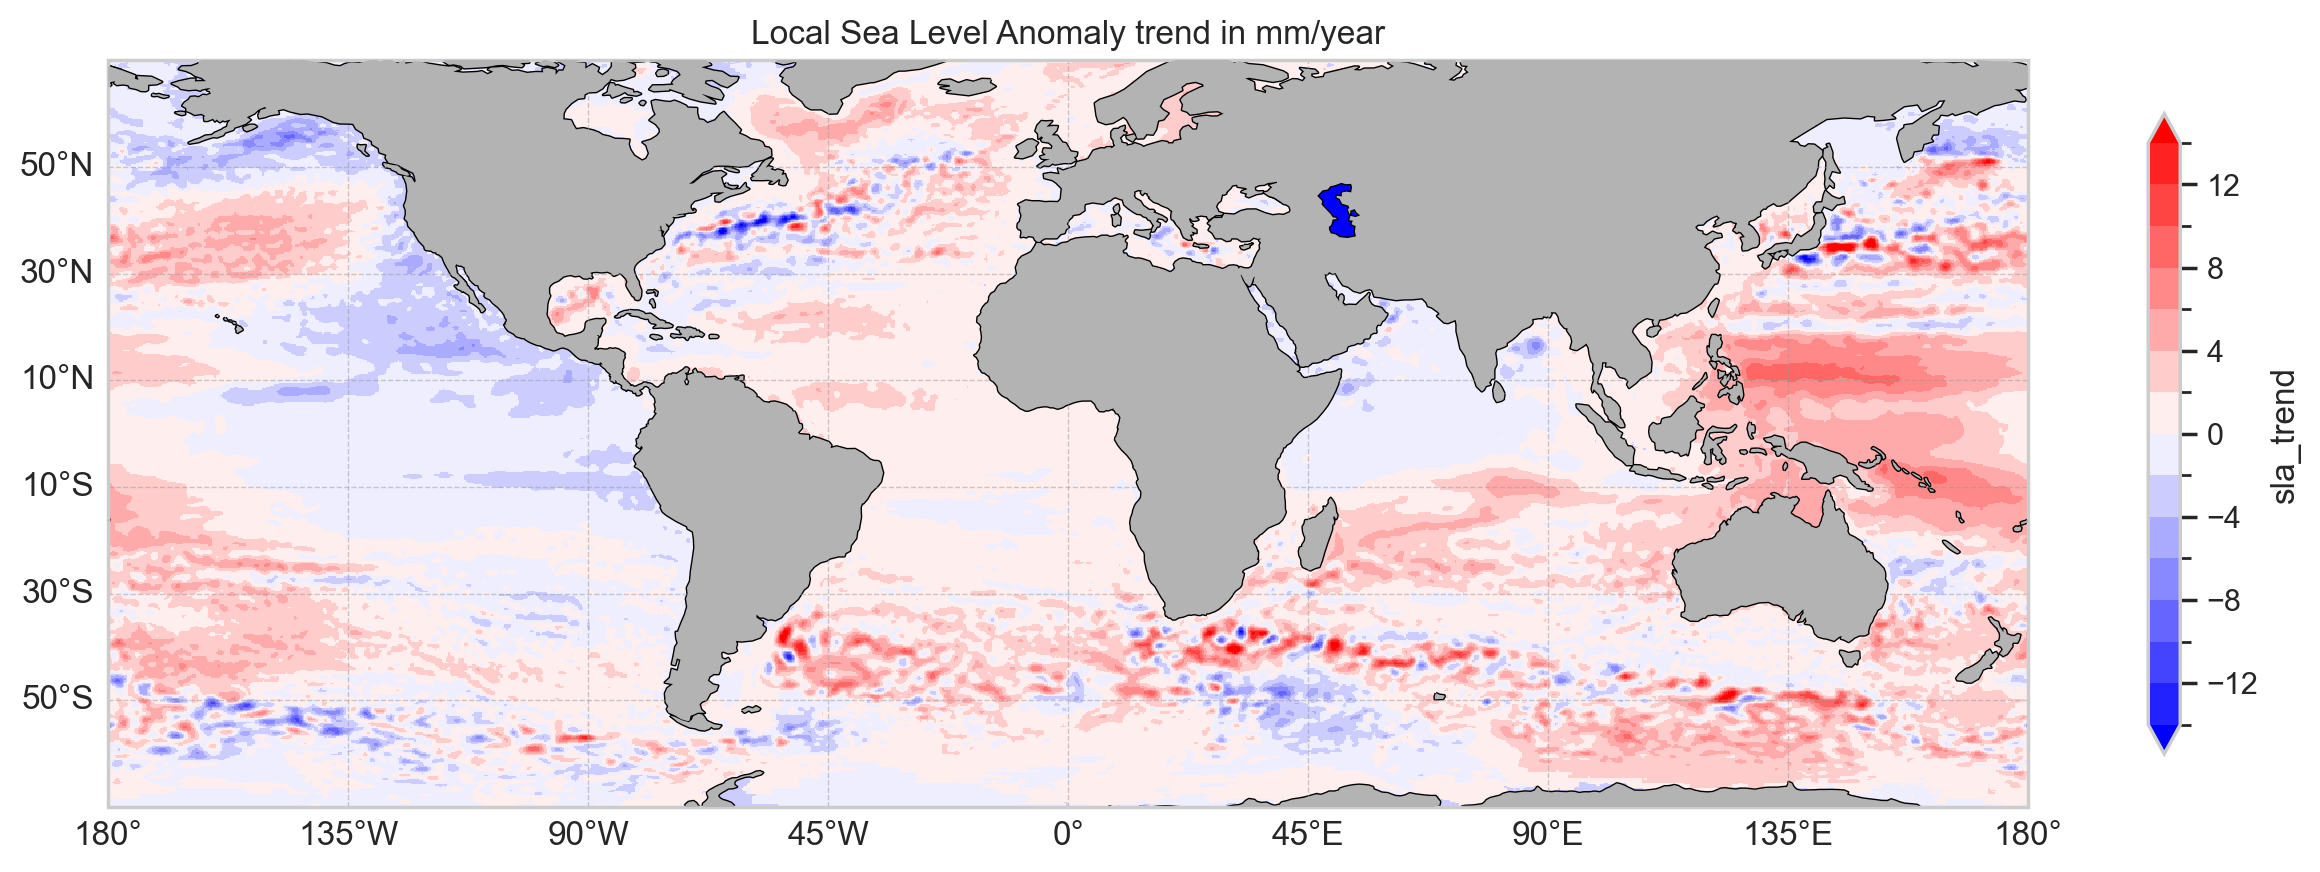

In [23]:
fig, proj, ax = create_map()
# fig, proj, ax = create_map(extent=[-90, 0, 0, 80])

((ssh['sla_trend']-global_sla_trend)*365*1000).plot(transform=proj, ax=ax, 
                     levels=15, vmin=-14, vmax=14, 
                     cmap=mpl.colormaps.get_cmap('bwr'),                     
                     cbar_kwargs={'shrink': 0.8})
ax.add_feature(cfeature.LAND, facecolor=[0.7]*3, zorder=100)
ax.set_title("Local Sea Level Anomaly trend in mm/year")

# Steric contributions to SLA trends

We shall now focus on the core of the P6 project: 
$$TSLA = -\int_{-H}^{0} \alpha \Delta T \,dz$$
$$HSLA =  \int_{-H}^{0} \beta \Delta S \,dz$$

## Grid elements

But we first need the grid elements to compute the vertical and horizontal averages correctly:

In [24]:
def get_dA(ds):
    # Earth Radius in meters:
    R = 6.37e6  
    # we know already that the spacing of the points is one degree latitude:
    dϕ = np.deg2rad(1.)
    dλ = np.deg2rad(1.)
    # Apply formulae for area element for lat-lon coordinates:
    dA = R**2 * dϕ * dλ * np.cos(np.deg2rad(ds["lat"]))
    return xr.DataArray(dA, dims='lat', name='dA', attrs={'unit': 'm2', 'long_name': 'Grid surface elements'})

def get_dz(ds):
    depth = ds['depth'].values
    dz_0 = depth[0] + (depth[1]-depth[0])/2
    dz_i = (depth[1:-1]-depth[:-2])/2 + (depth[2:]-depth[1:-1])/2
    dz_N = (depth[-1]-depth[-2])/2
    dz = np.concatenate((dz_0[np.newaxis], dz_i, dz_N[np.newaxis]))
    return xr.DataArray(dz, dims='depth', name='dZ', attrs={'unit': 'm', 'long_name': 'Grid vertical thickness'})

en4['dA'] = get_dA(en4);
en4['dZ'] = get_dz(en4);

## Thermal and haline coefficients

Now let's use the GSW library to compute the absolute salinity and conservative temperature:

In [25]:
en4['pres'] = gsw.p_from_z(-en4['depth'], en4['lat'])
en4['pres'].compute().persist()

en4['SA'] = gsw.SA_from_SP(en4['salinity'], en4['pres'], en4['lon'], en4['lat'])
en4['SA'].attrs = {'unit': 'g/kg', 'long_name': 'Absolute Salinity'}

en4['CT'] = gsw.CT_from_t(en4['SA'], (en4['temperature']-273.15), en4['pres'])
en4['CT'].attrs = {'unit': 'degC', 'long_name': 'Conservative Temperature of seawater from in-situ temperature'}

and finaly we can compute the $\alpha$ and $\beta$ coefficients:

In [26]:
en4['alpha'] = gsw.alpha(SA = en4['SA'], CT = en4['CT'], p = en4['pres'])
en4['alpha'].attrs = {'unit': '1/K', 'long_name': 'Thermal expansion coefficient'}

en4['beta'] = gsw.beta(SA = en4['SA'], CT = en4['CT'], p = en4['pres'])
en4['beta'].attrs = {'unit': 'kg/g', 'long_name': 'Haline contraction coefficient'}

Let's have a look at those coefficients

Check should compare to:

https://www.science.org/doi/10.1126/sciadv.abq0793#:~:text=In%20the%20global%20ocean%2C%20the,C%E2%88%921%20in%20tropical%20waters.

https://en.wikipedia.org/wiki/Haline_contraction_coefficient#/media/File:Beta_30W.png

In [27]:
%%time
da = en4['alpha'].isel(depth=0).weighted(en4['dA']).mean(dim=['time', 'lon'])
da.attrs = en4['alpha'].attrs

CPU times: user 15.7 ms, sys: 1.2 ms, total: 16.9 ms
Wall time: 16.3 ms


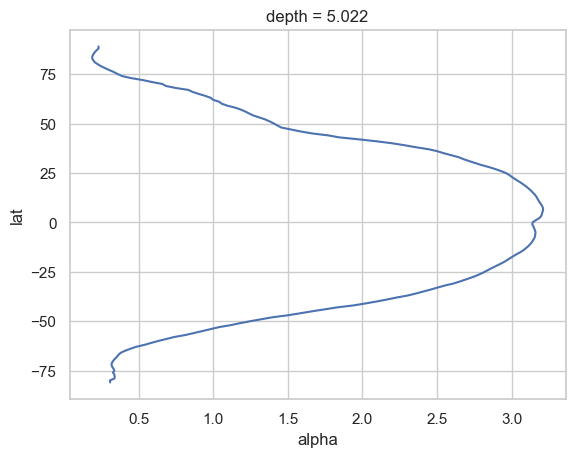

In [28]:
(da/1e-4).plot(y='lat')

In [29]:
%%time
da = en4['beta'].sel(lon=360-30, method='nearest').weighted(en4['dA']).mean(dim=['time']).compute().persist()
da.attrs = en4['beta'].attrs

CPU times: user 284 ms, sys: 40.8 ms, total: 325 ms
Wall time: 33.6 s


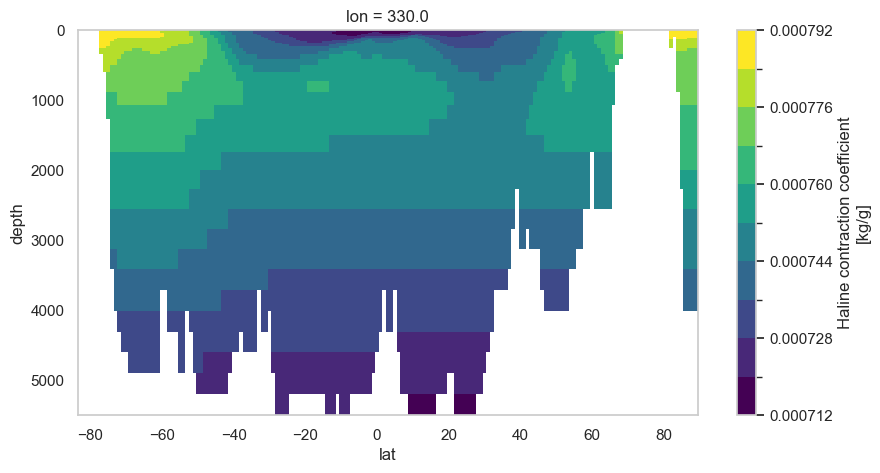

In [30]:
da.plot(yincrease=False, levels=12, figsize=(10,5))

## Steric heights

In order to compute the steric height contribution from changes in temperature or salinity, we need a reference level for the integration:

In [31]:
en4

<xarray.Dataset>
Dimensions:                          (depth: 42, time: 832, bnds: 2, lat: 173,
                                      lon: 360)
Coordinates:
  * depth                            (depth) float32 5.022 15.08 ... 5.35e+03
  * lat                              (lat) float32 -83.0 -82.0 ... 88.0 89.0
  * lon                              (lon) float32 1.0 2.0 3.0 ... 359.0 360.0
  * time                             (time) datetime64[ns] 1950-01-16T12:00:0...
Dimensions without coordinates: bnds
Data variables: (12/15)
    depth_bnds                       (time, depth, bnds) float32 dask.array<chunksize=(1, 42, 2), meta=np.ndarray>
    salinity                         (time, depth, lat, lon) float32 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
    salinity_observation_weights     (time, depth, lat, lon) float32 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
    salinity_uncertainty             (time, depth, lat, lon) float32 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
    temperature                      (time, depth, lat, lon) float32 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
    temperature_observation_weights  (time, depth, lat, lon) float32 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
    ...                               ...
    dZ                               (depth) float64 10.05 10.07 ... 299.1 149.6
    pres                             (depth, lat) float64 5.076 ... 5.477e+03
    SA                               (time, depth, lat, lon) float64 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
    CT                               (time, depth, lat, lon) float64 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
    alpha                            (time, depth, lat, lon) float64 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
    beta                             (time, depth, lat, lon) float64 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
Attributes: (12/21)
    Conventions:            CF-1.0
    DSD_entry_id:           UKMO-L4UHFnd-GLOB-v01
    GDS_version_id:         v1.7
    contact:                Simon Good - simon.good@metoffice.gov.uk
    creation_date:          2017-04-21 21:12:08.123 -00:00
    easternmost_longitude:  362.5
    ...                     ...
    start_date:             2001-01-01 UTC
    start_time:             00:00:00 UTC
    stop_date:              2001-01-01 UTC
    stop_time:              00:00:00 UTC
    title:                  Temperature and salinity analysis
    westernmost_longitude:  0.5

In [32]:
H  = en4["depth"].max().item() # in meters
H

5350.27197265625

In [33]:
en4

<xarray.Dataset>
Dimensions:                          (depth: 42, time: 832, bnds: 2, lat: 173,
                                      lon: 360)
Coordinates:
  * depth                            (depth) float32 5.022 15.08 ... 5.35e+03
  * lat                              (lat) float32 -83.0 -82.0 ... 88.0 89.0
  * lon                              (lon) float32 1.0 2.0 3.0 ... 359.0 360.0
  * time                             (time) datetime64[ns] 1950-01-16T12:00:0...
Dimensions without coordinates: bnds
Data variables: (12/15)
    depth_bnds                       (time, depth, bnds) float32 dask.array<chunksize=(1, 42, 2), meta=np.ndarray>
    salinity                         (time, depth, lat, lon) float32 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
    salinity_observation_weights     (time, depth, lat, lon) float32 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
    salinity_uncertainty             (time, depth, lat, lon) float32 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
    temperature                      (time, depth, lat, lon) float32 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
    temperature_observation_weights  (time, depth, lat, lon) float32 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
    ...                               ...
    dZ                               (depth) float64 10.05 10.07 ... 299.1 149.6
    pres                             (depth, lat) float64 5.076 ... 5.477e+03
    SA                               (time, depth, lat, lon) float64 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
    CT                               (time, depth, lat, lon) float64 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
    alpha                            (time, depth, lat, lon) float64 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
    beta                             (time, depth, lat, lon) float64 dask.array<chunksize=(1, 42, 173, 360), meta=np.ndarray>
Attributes: (12/21)
    Conventions:            CF-1.0
    DSD_entry_id:           UKMO-L4UHFnd-GLOB-v01
    GDS_version_id:         v1.7
    contact:                Simon Good - simon.good@metoffice.gov.uk
    creation_date:          2017-04-21 21:12:08.123 -00:00
    easternmost_longitude:  362.5
    ...                     ...
    start_date:             2001-01-01 UTC
    start_time:             00:00:00 UTC
    stop_date:              2001-01-01 UTC
    stop_time:              00:00:00 UTC
    title:                  Temperature and salinity analysis
    westernmost_longitude:  0.5

In [34]:
%%time
en4['DT'] = en4['temperature'] - en4['temperature'].mean(dim='time')
en4['TSLA'] = (en4['DT']*en4['alpha']*en4['dZ']).where(en4["depth"] <= H).sum(dim='depth')
en4['TSLA'] = en4['TSLA'].compute().persist()
en4['TSLA'].attrs = {'unit': 'm', 'long_name': 'Thermosteric height'}


CPU times: user 3.92 s, sys: 1.91 s, total: 5.83 s
Wall time: 3min 43s


In [35]:
%%time
en4['DS'] = en4['SA'] - en4['SA'].mean(dim='time')
en4['HSLA'] = -(en4['DS']*en4['beta']*en4['dZ']).where(en4["depth"] <= H).sum(dim='depth')
en4['HSLA'] = en4['HSLA'].compute().persist()
en4['HSLA'].attrs = {'unit': 'm', 'long_name': 'Halosteric height'}

CPU times: user 3.91 s, sys: 2.18 s, total: 6.08 s
Wall time: 3min 11s


In [36]:
en4['TSLA']

<xarray.DataArray 'TSLA' (time: 832, lat: 173, lon: 360)>
array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.01148119, 0.01155055, 0.0116143 , ..., 0.01106353,
         0.01122576, 0.01138133],
        [0.01088748, 0.01096079, 0.01102675, ..., 0.0109001 ,
         0.01093724, 0.01083378],
        [0.00991768, 0.00996472, 0.01002065, ..., 0.00997959,
         0.01000657, 0.00987519]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
...
        [0.02857094, 0.02855429, 0.02844925, ..., 0.02781936,
         0.0280857 , 0.02842634],
        [0.02504204, 0.02533945, 0.02547101, ..., 0.02469372,
         0.02482227, 0.02492688],
        [0.02099711, 0.02112561, 0.02119381, ..., 0.02083281,
         0.02090177, 0.02093546]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.02451475, 0.02422481, 0.0239533 , ..., 0.02386365,
         0.02408031, 0.02437118],
        [0.02199808, 0.02226734, 0.02239652, ..., 0.02174599,
         0.02187625, 0.02189143],
        [0.01839568, 0.01851159, 0.01857833, ..., 0.01831039,
         0.01838187, 0.01833751]]])
Coordinates:
  * lat      (lat) float32 -83.0 -82.0 -81.0 -80.0 -79.0 ... 86.0 87.0 88.0 89.0
  * lon      (lon) float32 1.0 2.0 3.0 4.0 5.0 ... 356.0 357.0 358.0 359.0 360.0
  * time     (time) datetime64[ns] 1950-01-16T12:00:00 1950-02-15 ... 2019-04-16
Attributes:
    unit:       m
    long_name:  Thermosteric height

## Local trends of steric height components

In [37]:
def compute_trend(ds, vname, time='time'):
    # For time:
    ds['t'] = xr.DataArray(ds[time].to_pandas().index.to_julian_date().values, dims=time, name='juld')
    sstt = ((ds['t']-ds['t'].mean(dim=time))**2).sum(dim=time)

    # For vname:
    ssyy = ((ds[vname]-ds[vname].mean(dim=time))**2).sum(dim=time)

    # For time vs vname:
    ssty = (((ds['t'] - ds['t'].mean(dim=time)) * (ds[vname] - ds[vname].mean(dim=time))).sum(dim=time))

    # Trend:
    trend = ssty / sstt  # [unit] / days
    
    return trend

Let's define the time period to look at:

1993-2010 for instance, to compare with results from [Meyssignac et al, 2012](https://www.sciencedirect.com/science/article/pii/S0264370712000464)


In [38]:
# ds = en4.where(en4['time']>=ssh['time'].min(), drop=True).where(en4['time']<=ssh['time'].max(), drop=True)
ds = en4.where(en4['time']>=pd.to_datetime('19930101'), drop=True).where(en4['time']<pd.to_datetime('20110101'), drop=True)

and compute trends:

In [39]:
%%time
ds['HSLA_trend'] = compute_trend(ds, 'HSLA').compute().persist()
ds['TSLA_trend'] = compute_trend(ds, 'TSLA').compute().persist()

CPU times: user 201 ms, sys: 140 ms, total: 342 ms
Wall time: 343 ms


In [40]:
global_steric_trend = (ds['TSLA_trend']+ds['HSLA_trend']).weighted(ds['dA'].fillna(0)).mean()
global_steric_trend*365*1000  # mm/year

<xarray.DataArray ()>
array(1.04305654)

Text(0.5, 1.0, 'Local Steric Sea Level Anomaly trend in mm/year')

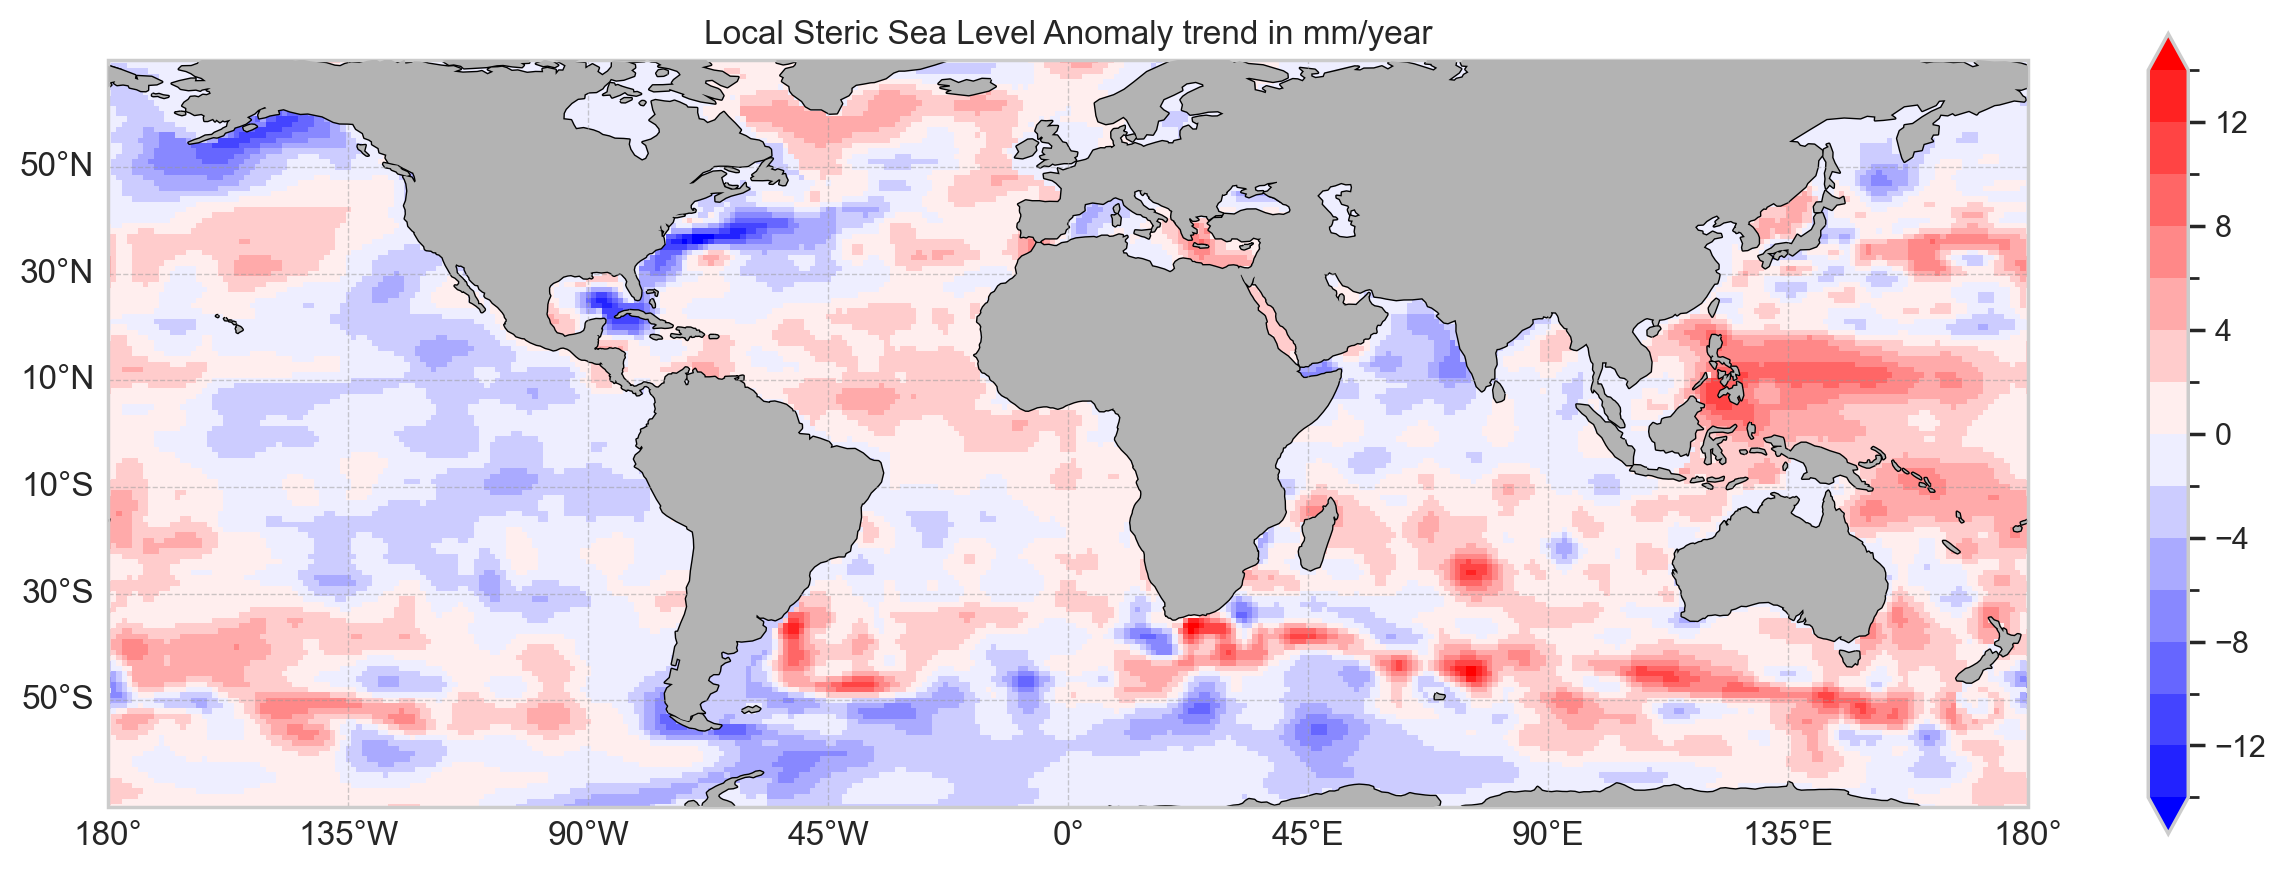

In [41]:
fig, proj, ax = create_map()
((ds['TSLA_trend']+ds['HSLA_trend']-global_steric_trend)*365*1000).plot(transform=proj, ax=ax,   
                     levels=15, vmin=-14, vmax=14, 
                     cmap=mpl.colormaps.get_cmap('bwr'))
ax.add_feature(cfeature.LAND, facecolor=[0.7]*3, zorder=100)
ax.set_title("Local Steric Sea Level Anomaly trend in mm/year")

## Compare steric trend to altimetry

You shall now interpolate all sea level trends and compare them on maps



Text(0.5, 1.0, 'Local Sea Level Anomaly trend in mm/year')

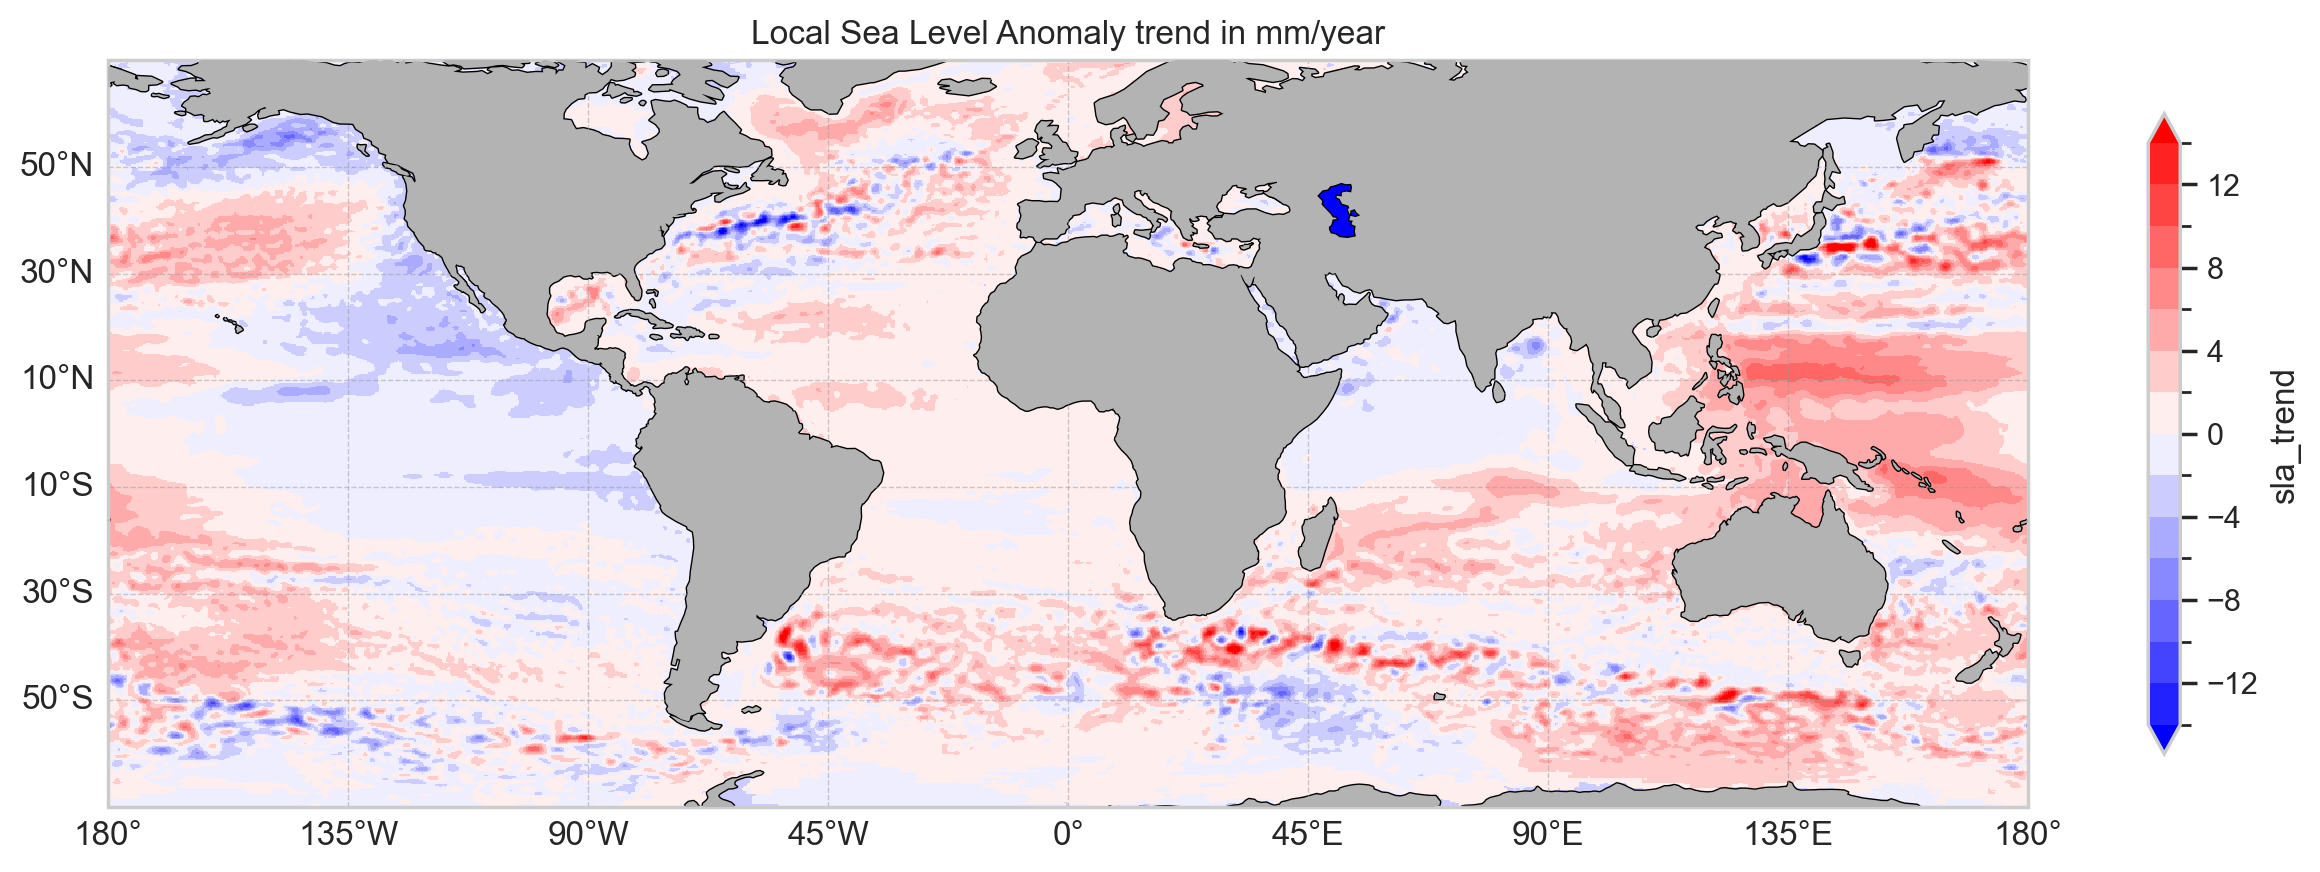

In [42]:
fig, proj, ax = create_map()
# fig, proj, ax = create_map(extent=[-90, 0, 0, 80])

((ssh['sla_trend']-global_sla_trend)*365*1000).plot(transform=proj, ax=ax, 
                     levels=15, vmin=-14, vmax=14, 
                     cmap=mpl.colormaps.get_cmap('bwr'),                     
                     cbar_kwargs={'shrink': 0.8})
ax.add_feature(cfeature.LAND, facecolor=[0.7]*3, zorder=100)
ax.set_title("Local Sea Level Anomaly trend in mm/year")

## Timeseries

In [ ]:
#we compute the mean over latitude and longitude weighted by surface element
en4['mean_HSLA'] = en4['HSLA'].weighted(en4['dA']).mean(dim = ['lat', 'lon'])

<Axes: xlabel='time'>

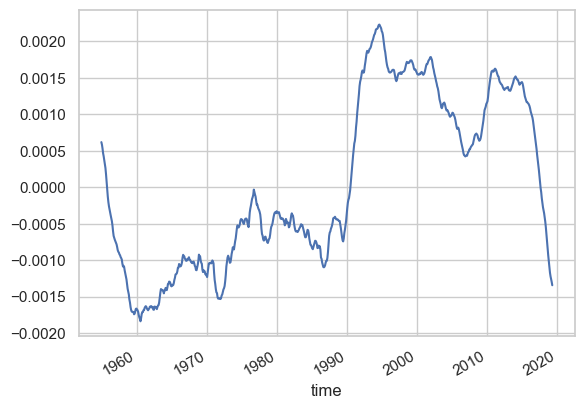

In [ ]:
# we plot the series
hsla_data = en4['mean_HSLA'].fillna("nearest").to_pandas()
moving_average_hsla = hsla_data.rolling(window= 60).mean()
moving_average_hsla.plot()

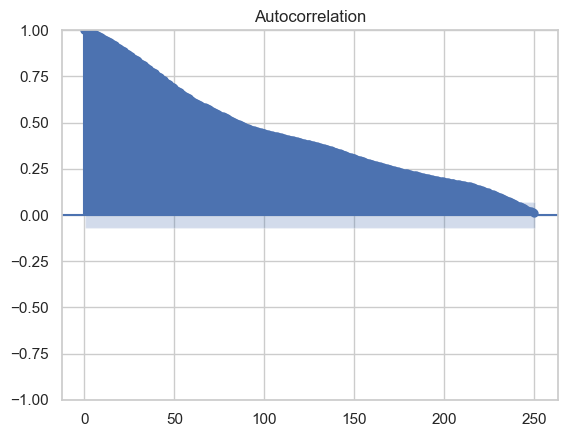

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
# we plot the autocorrelation to see what the most reasonable number of lags
moving_average_hsla = moving_average_hsla.dropna()
moving_average_hsla.reset_index(drop=True)

plot_acf(moving_average_hsla, lags = 250,bartlett_confint = False);

We decided that number of lags could be at 200

In [304]:
from statsmodels.tsa.ar_model import AutoReg

model = AutoReg(moving_average_hsla, lags=200)
fitted_model = model.fit()
future_steps = 700

extended_data = moving_average_hsla.dropna().tolist()
error = (moving_average_hsla - fitted_model.fittedvalues).fillna(0).values
error_model_fit = AutoReg(error, lags=10).fit()


/Users/mac/anaconda3/envs/ds2-coiled-2025-binder/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/Users/mac/anaconda3/envs/ds2-coiled-2025-binder/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/mac/anaconda3/envs/ds2-coiled-2025-binder/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Users/mac/anaconda3/envs/ds2-coiled-2025-binder/lib/python3.11/site-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


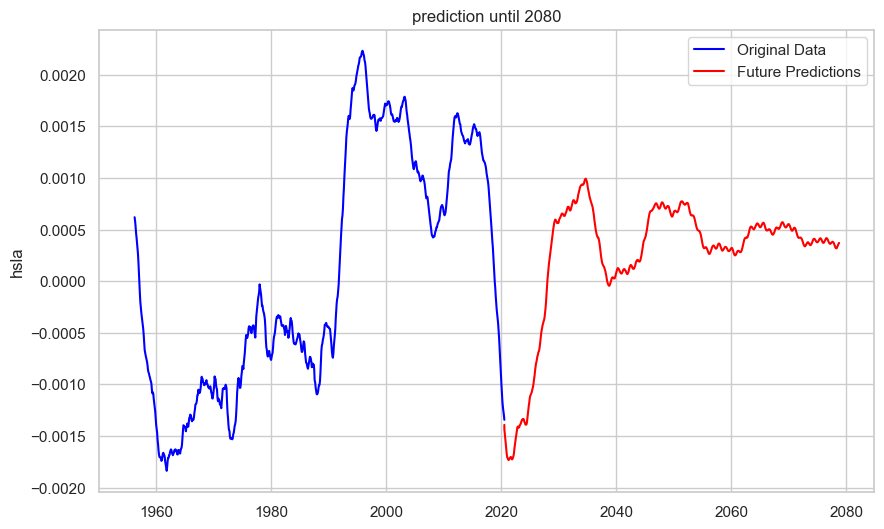

In [311]:
# prediction using our model
future_steps = 700
predictions_hsla = fitted_model.predict(start=len(moving_average_hsla), end=len(moving_average_hsla)+future_steps)
plt.figure(figsize=(10, 6))

# frist use date indices
total_elements = moving_average_hsla.shape[0]
start_date = pd.Timestamp('1956-03-16 12:00:00')
dates_moving_average = [start_date + pd.DateOffset(months=i) for i in range(total_elements)]
moving_average_hsla.index = dates_moving_average
dates_prediction = [dates_moving_average[-1]] + [dates_moving_average[-1] + pd.DateOffset(months=i) for i in range(future_steps)] 
predictions_hsla.index = dates_prediction
plt.plot(
    moving_average_hsla.index,
    moving_average_hsla,
    label='Original Data',
    color='blue'
)

plt.plot(
    predictions_hsla.index,
    predictions_hsla,
    label='Future Predictions',
    color='red'
)
plt.ylabel('hsla')
plt.legend()
plt.title("prediction until 2080");

<Axes: xlabel='time'>

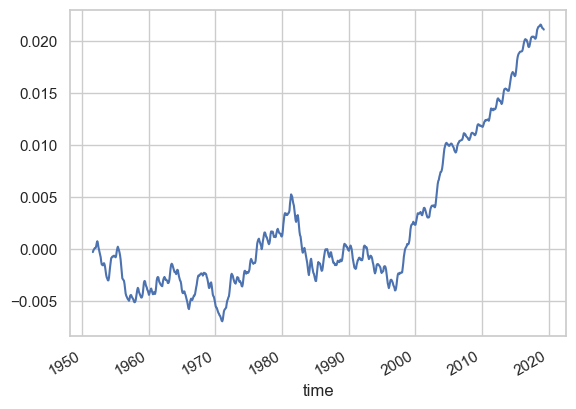

In [282]:
en4['mean_TSLA'] = en4['TSLA'].weighted(en4['dA']).mean(dim = ['lat', 'lon'])
tsla_data = en4['mean_TSLA'].fillna("nearest").to_pandas()
moving_average_tsla = tsla_data.rolling(window= 20).mean()
moving_average_tsla.plot()


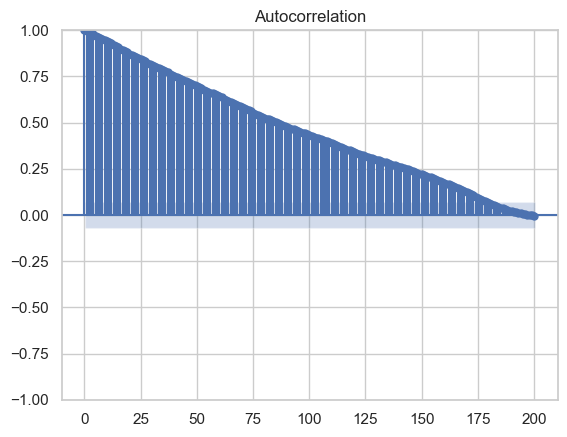

In [293]:
moving_average_tsla = moving_average_tsla.dropna()
moving_average_tsla.reset_index(drop=True)
plot_acf(moving_average_tsla, lags= 200, bartlett_confint = False);

In [315]:
model = AutoReg(moving_average_tsla, lags=75)
fitted_model = model.fit()


/Users/mac/anaconda3/envs/ds2-coiled-2025-binder/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/Users/mac/anaconda3/envs/ds2-coiled-2025-binder/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/mac/anaconda3/envs/ds2-coiled-2025-binder/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Users/mac/anaconda3/envs/ds2-coiled-2025-binder/lib/python3.11/site-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


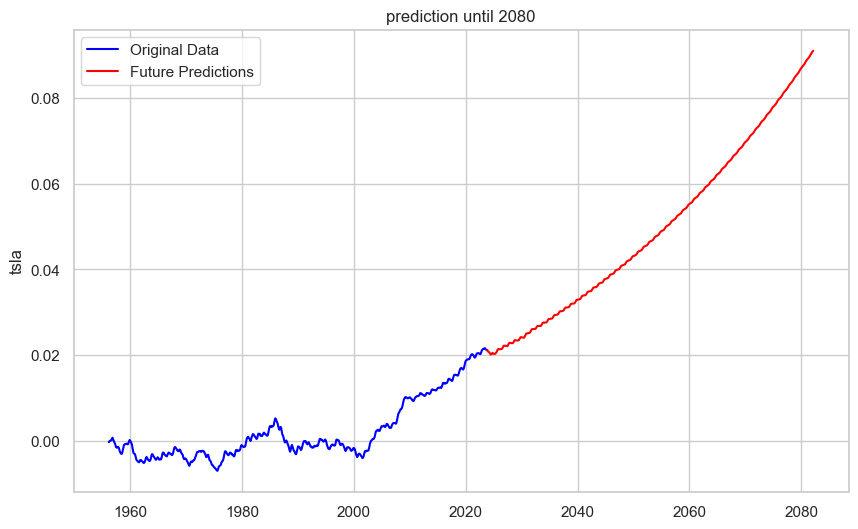

In [317]:
# prediction using our model
future_steps = 700
predictions_tsla = fitted_model.predict(start=len(moving_average_tsla), end=len(moving_average_tsla)+future_steps)
plt.figure(figsize=(10, 6))

# frist use date indices
total_elements = moving_average_tsla.shape[0]
start_date = pd.Timestamp('1956-03-16 12:00:00')
dates_moving_average = [start_date + pd.DateOffset(months=i) for i in range(total_elements)]
moving_average_tsla.index = dates_moving_average
dates_prediction = [dates_moving_average[-1]] + [dates_moving_average[-1] + pd.DateOffset(months=i) for i in range(future_steps)] 
predictions_tsla.index = dates_prediction
plt.plot(
    moving_average_tsla.index,
    moving_average_tsla,
    label='Original Data',
    color='blue'
)

plt.plot(
    predictions_tsla.index,
    predictions_tsla,
    label='Future Predictions',
    color='red'
)
plt.ylabel('tsla')
plt.legend()
plt.title("prediction until 2080");